# **NLP Analysis — electricalworld.com | Electronics & Technology**

### **Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import CountVectorizer
from sentence_transformers import SentenceTransformer
from transformers import pipeline as hf_pipeline

# Own libraries
import sys
if '../src' not in sys.path:
    sys.path.append('../src')
import nlp

### **Sector & Company Configuration**

In [2]:
TARGET = "electricalworld.com"
CAT = "Electronics & Technology"

### **Data Load**

Loading cleaned dataset from the **EDA Notebook**

In [3]:
df_clean = pd.read_csv("../datasets/df_clean")
df_clean.head()

,Unnamed: 0,category,company,description,title,review,stars
0,0,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
1,1,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds...,Great service from the Richer Sounds team at S...,5
2,2,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative...,Wanted a TV for an 84 year old relative whos s...,5
3,3,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
4,4,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


## **Methodology & Design Decisions**

The goal of this pipeline is to understand **what topics
customers talk about** in their reviews and **whether they speak
positively or negatively** about each topic — for our company and for
every competitor in the same sector. The full process can be divided
into four conceptual blocks: text representation, topic assignment,
sentiment labelling, and comparative analysis.

---

### **Step 1 — Sentence Embeddings (SBERT)**

- Every review is converted into a **dense numerical vector** of 384
dimensions using the `all-MiniLM-L6-v2` SentenceTransformer model.
This vector captures the full semantic meaning of the review — not just
which words appear, but what the sentence *means* in context.

- Traditional approaches (bag-of-words, TF-IDF) treat text as a set of
independent words and miss meaning entirely. A review saying
*"the parcel took three weeks"* and a review saying *"still waiting for
my package"* share no words but mean the same thing. SBERT maps both
into nearly identical vectors because it was pre-trained on millions of
sentence pairs to understand semantic similarity.

- We chose `all-MiniLM-L6-v2` specifically because it offers an excellent
balance between speed and quality — it runs on CPU in a reasonable time
while producing embeddings that are competitive with much larger models
for short-to-medium review texts.

SBERT is loaded **once** and reused for embedding reviews, encoding seed
words, and computing centroids. This guarantees that all vectors live in
the same geometric space — a requirement for cosine similarity
comparisons to be meaningful.

---

### **Step 2 — Macro Topic Definition via Seed Words**

Instead of letting an algorithm discover arbitrary topics from scratch,
we define **8 business-meaningful macro topics** manually, each
described by a list of seed words that represent what that topic is
about:

| # | Macro Topic | Example seeds |
|---|-------------|---------------|
| 0 | Delivery & Shipping | delivery, courier, parcel, arrived, delayed |
| 1 | Order & Purchase Process | order, checkout, transaction, confirmation |
| 2 | Returns, Refunds & Cancellations | refund, return, cancelled, money back |
| 3 | Customer Service & Support | support, agent, staff, helpful, response |
| 4 | Product Quality & Condition | quality, faulty, damaged, refurbished |
| 5 | Price & Value | price, value, affordable, overpriced |
| 6 | Website & Online Experience | website, app, login, navigation, error |
| 7 | Repair & Technical Service | repair, technician, warranty, diagnostic |

Each seed list is then encoded with SBERT and averaged into a single
**centroid vector** — a point in 384-dimensional space that represents
the semantic centre of that topic.

Fully unsupervised topic models (like standard BERTopic or LDA) discover
topics from the data, which is powerful but produces results that are
unpredictable and hard to interpret — especially with a small target
company corpus of only 100 reviews. The discovered topics would reflect
the statistical structure of the data rather than the business questions
we actually want to answer.

By defining topics through seed words, we encode domain knowledge
directly into the model. The topics correspond exactly to the dimensions
a Customer Experience team cares about: delivery, quality, price, service,
and so on. This makes the results immediately actionable without requiring
a data scientist to interpret what *"T7: customer service, purchase, buy, item"* means.

---

### **Step 3 — Direct Cosine Similarity Assignment**

For each review, we compute the **cosine similarity** between its SBERT
embedding and each of the 8 topic centroids. The review is then assigned
to the macro topic with the highest similarity score. If the best score
is below a minimum threshold (default 0.05), the review is labelled
*General / Other*.
review embedding  ──cosine sim──►  [Delivery: 0.31, Orders: 0.18,
Refunds: 0.12, Service: 0.42, ...]
└── assigned to: Customer Service

We deliberately replaced BERTopic's HDBSCAN clustering step with direct
cosine similarity for the topic assignment. HDBSCAN is a density-based
clustering algorithm — it requires a minimum number of nearby points to
form a cluster, and any review that doesn't fit a dense region is
discarded as an outlier (topic -1). With only 100 reviews in the target
company, HDBSCAN was assigning 86% of reviews to outliers because the
embedding space was too sparse for density-based clustering to work.

Direct cosine similarity has none of these limitations:
- **Every review gets assigned** — there is no minimum density requirement
- **The decision is deterministic** — the same review always maps to the
  same topic regardless of what other reviews are present
- **The threshold is interpretable** — similarity 0.05 means "almost no
  relation to any topic", which is a meaningful business concept
- **Target and competitors use the exact same decision boundary** — since
  centroids are computed once from seeds and shared, the comparison is fair

The threshold of 0.05 is intentionally very permissive. Cosine similarity
between two random SBERT vectors is typically near zero, so any review
with even a weak topical signal will exceed it. In practice, *General /
Other* should contain fewer than 2% of reviews — truly off-topic text
such as reviews in a foreign language or empty submissions.

---

### **Step 4 — Sentiment Labelling**

Each review is labelled as **positive**, **neutral**, or **negative**
based on its star rating:

| Stars | Sentiment | Score |
|-------|-----------|-------|
| 4–5   | Positive  | 0.95  |
| 3     | Neutral   | 0.70  |
| 1–2   | Negative  | 0.95  |

The dataset already contains explicit star ratings, which are a direct
ground-truth expression of customer satisfaction. Star ratings are in
fact *more* reliable than a transformer sentiment model for this use case
because:

1. **No ambiguity** — a 1-star review is unambiguously negative regardless
   of the words used. A transformer model might classify a sarcastic
   positive-sounding 1-star review incorrectly.
2. **Speed** — deriving sentiment from stars is instantaneous. Running a
   transformer model on 5,729 reviews takes 45–70 minutes on CPU.
3. **Consistency** — the same rating scale is applied to all companies,
   making comparisons fair.

A transformer sentiment model (`cardiffnlp/twitter-roberta-base-sentiment`)
is available as an alternative for datasets without star ratings or when
a more nuanced three-class sentiment is required.

---

### **Step 5 — Competitive Aggregation**

For each macro topic, we compute:
- **% positive**, **% neutral**, **% negative** reviews
- **Net sentiment** = % positive − % negative (range: −100 to +100)
- **Dominant sentiment** = the category with the highest percentage

This is done separately for the target company and the aggregate of all
competitors, then merged into a **head-to-head comparison** table with
a gap column:

gap = net_sentiment_target − net_sentiment_competitors

A positive gap means we outperform the sector on that topic and a negative gap means we underperform.

Net sentiment is a single number that compresses three percentages into
one interpretable score. It is directionally consistent — higher is
always better — and it produces a natural ranking of topics from
strongest to weakest. The gap metric is the key business output: it
tells the CX team not just *how we perform* but *how we perform relative
to what customers experience elsewhere in the sector*. A −100 net
sentiment on refunds is alarming in isolation; it is catastrophic if
competitors score +20 on the same topic.

---

### **Step 6 — Root Cause Extraction**

For every macro topic where our gap falls below a threshold (default −5),
the pipeline:
1. Identifies which specific reviews are negative in that topic
2. Prints the raw review text verbatim, sorted by star rating ascending
3. Generates a word frequency comparison between our negative reviews
   and competitors' negative reviews in the same topic

Aggregate metrics tell you *what* is broken. Raw reviews tell you *why*.
The word frequency comparison is particularly powerful — if our negative
delivery reviews are dominated by *"three weeks"*, *"no update"*, and
*"tracking"* while competitors' negative delivery reviews are dominated
by *"damaged"* and *"packaging"*, the root causes are completely
different and require completely different operational fixes.

Limiting the raw review extraction to negative reviews in underperforming
topics keeps the output focused. A CX manager reading this report does
not need to see 40 reviews — they need to see the 5 most representative
complaints, with enough context to escalate to the right team.

### **Design Summary**

| Decision | Alternative considered | Reason for choice |
|---|---|---|
| SBERT embeddings | TF-IDF, word2vec | Captures sentence meaning, not just word frequency |
| Seed-defined macro topics | Unsupervised BERTopic | Produces business-relevant, interpretable topics by design |
| Cosine similarity assignment | HDBSCAN clustering | Works with small corpora; no outlier problem; deterministic |
| Star-based sentiment | Transformer model | Ground truth already in data; faster; more reliable |
| Net sentiment metric | Raw positive % | Single number enables direct ranking and gap comparison |
| Fit on competitors, transform target | Fit on both separately | Larger corpus produces more stable semantic space; fair comparison |

## **NLP Topic Analysis & Results**



In [4]:
max_reviews_shown=5

results = nlp.run_macro_pipeline(
    df=df_clean,
    target=TARGET,
    use_star_sentiment=True,
    max_reviews_shown=max_reviews_shown,
    threshold=0.05       # lower = fewer General/Other, raise if needed
)

df_t = results['df_target']
df_c = results['df_comp']


[1/6] Splitting dataset ...
  Target 'electricalworld.com'       : 100 reviews
  Competitors             : 5496 reviews (68 companies)

[2/6] Loading SBERT, embedding reviews & building centroids ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2341.22it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 2/2 [00:02<00:00,  1.49s/it]


  Building seed centroids ...
    [0] Delivery & Shipping                      (23 seeds)
    [1] Order & Purchase Process                 (19 seeds)
    [2] Returns, Refunds & Cancellations         (19 seeds)
    [3] Customer Service & Support               (26 seeds)
    [4] Product Quality & Condition              (23 seeds)
    [5] Price & Value                            (20 seeds)
    [6] Website & Online Experience              (24 seeds)
    [7] Repair & Technical Service               (20 seeds)

[3/6] Assigning macro topics to competitor reviews ...
  ✓ Assigned          : 5470 reviews
  ✓ General / Other   : 26 reviews (0.5%)

  Distribution:
    Repair & Technical Service                     1166  ████████
    Order & Purchase Process                       1130  ████████
    Returns, Refunds & Cancellations                797  █████
    Delivery & Shipping                             754  █████
    Price & Value                                   514  ███
    Product Quality

### **1. Topic Distribution — electricalworld.com & Competitors**

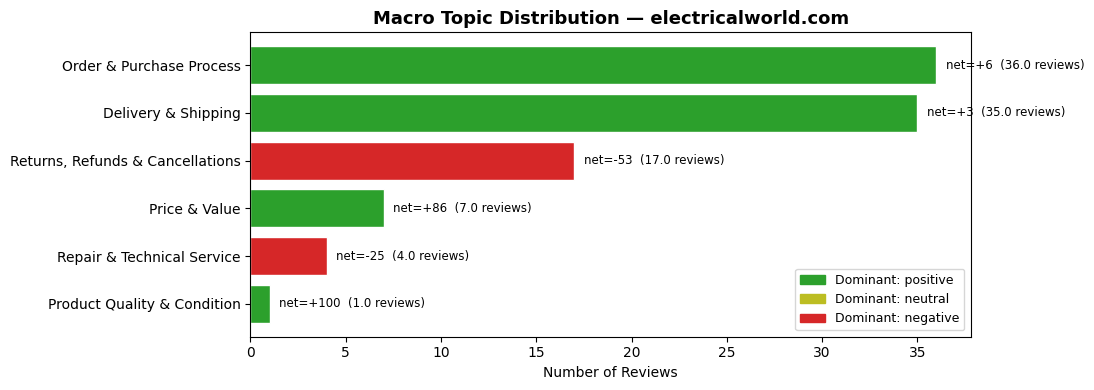

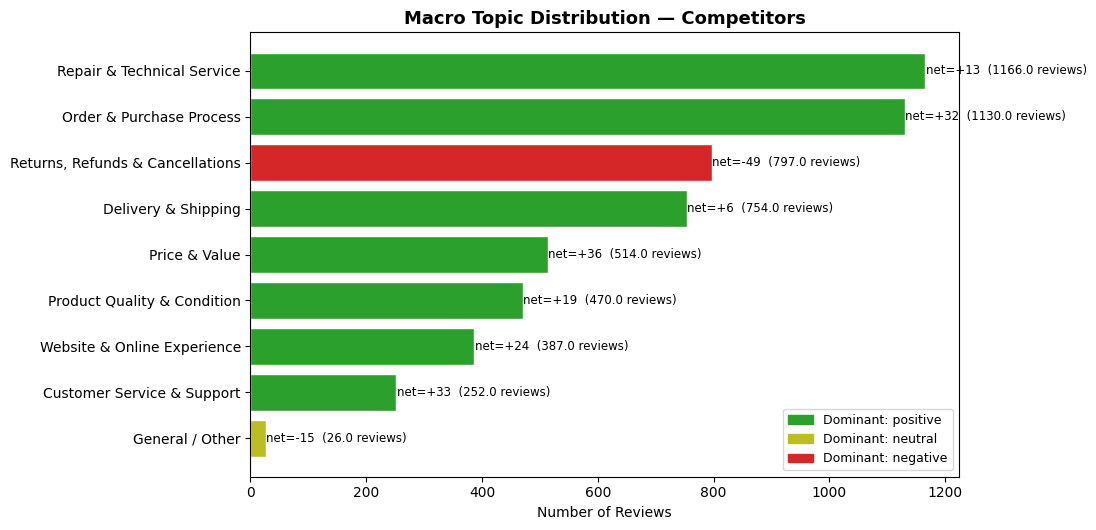

In [5]:
nlp.plot_macro_distribution(df_t, title=TARGET)
nlp.plot_macro_distribution(df_c, title="Competitors")

Looking at how our 100 reviews distribute across the macro topics, two
themes dominate the conversation: **Order & Purchase Process** (36
reviews) and **Delivery & Shipping** (35 reviews), together accounting
for 71% of all reviews. This makes sense for an electronics retailer —
the purchase journey and physical delivery are the two most tangible
touchpoints a customer has with the brand.

The net sentiment on both is weakly positive (+6 and +3 respectively),
which on the surface sounds acceptable but conceals a dangerous
polarisation — these topics contain both our happiest and our most
frustrated customers. The picture becomes clearer when we look at
**Returns, Refunds & Cancellations** (17 reviews, net −53): this is the
single most damaging topic in our profile, with more than half of
reviews in this category being negative.


On the other hand, the competitor picture tells a structurally different story.
**Repair & Technical Service** leads with 1,166 reviews (net +13),
followed by **Order & Purchase Process** with 1,130 reviews (net +32).
The sector is dominated by companies that sell refurbished electronics
and offer repair services — a customer base that is more technically
engaged and expects professional handling of complex transactions.

**Returns, Refunds & Cancellations** is the largest red bar in the
sector too (797 reviews, net −49), confirming that this is a
**sector-wide pain point** and not a problem unique to
electricalworld.com. The key difference is volume: competitors absorb
this negative topic across a much larger review base, diluting its
impact on the overall rating.

**Price & Value** (514 reviews, net +36), **Product Quality &
Condition** (470 reviews, net +19), **Website & Online Experience**
(387 reviews, net +24), and **Customer Service & Support** (252
reviews, net +33) all appear with healthy volumes and positive
sentiment in the competitor set — topics that are virtually absent or
unrepresented in electricalworld.com's profile.

### **2. Topic × Sentiment Heatmap**

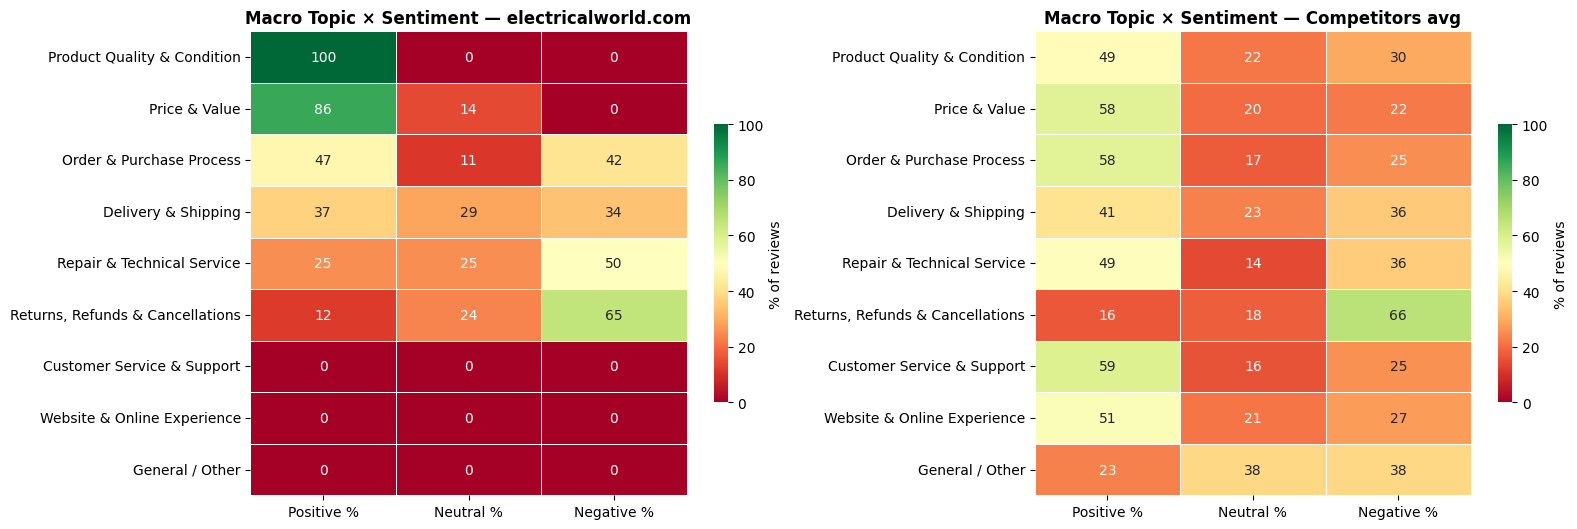

In [6]:
nlp.plot_macro_heatmap(df_t, df_c, target_name=TARGET)

The side-by-side heatmap is where the competitive gaps become
undeniable.

**electricalworld.com's profile:**
- Product Quality & Condition: 100% positive (1 review — too small)
- Price & Value: 86% positive, 0% negative — a genuine strength
- Order & Purchase Process: 47% positive, 42% negative — deeply split
- Delivery & Shipping: 37% positive, 34% negative — equally split
- Repair & Technical Service: 25% positive, 50% negative
- Returns, Refunds & Cancellations: 12% positive, 65% negative
- Customer Service, Website, General: 0% across all — no data

**Competitors' profile:**
- Most topics sit between 40–60% positive with 20–40% negative
- Even their worst topic (Returns at 16% positive, 66% negative)
  mirrors our returns profile — confirming sector-wide pain
- Their best topics (Customer Service at 59%, Website at 51%) show
  that positive service experiences are achievable in this sector

The most striking contrast is **Order & Purchase Process**: we score
47% positive vs their 58%, but our negative rate is 42% vs their 25%.
This 17-point gap in negative rates on our highest-volume topic is the
single most important number in this entire analysis.

### **3. Head-to-Head Net Sentiment — electricalworld.com vs Competitors**

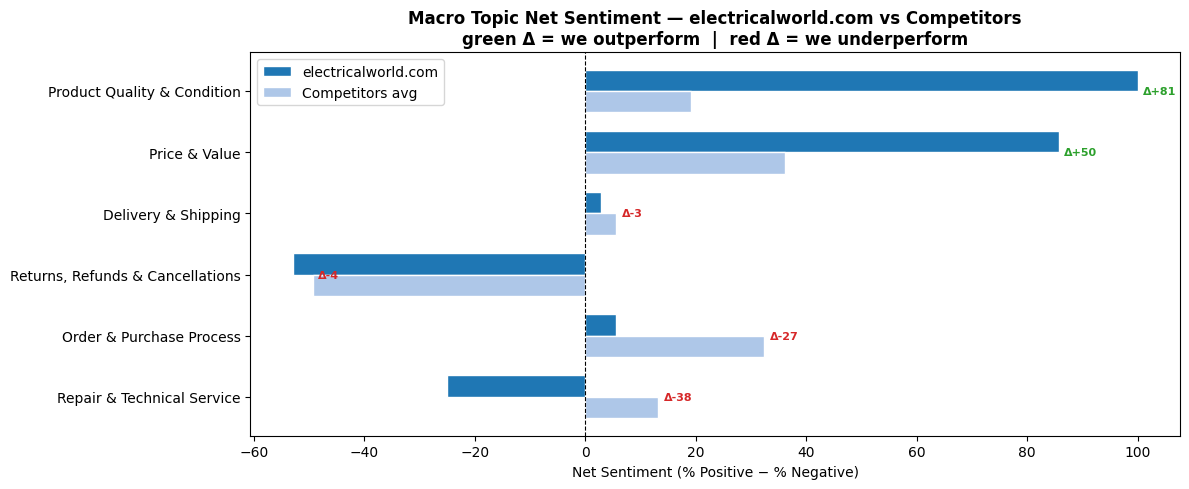


  MACRO STRENGTHS — electricalworld.com outperforms competitors
  ✅  Product Quality & Condition               net=+100  gap=+81
  ✅  Price & Value                             net=+86  gap=+50

  MACRO WEAKNESSES — electricalworld.com underperforms competitors
  ⚠️   Repair & Technical Service                net=-25  gap=-38
  ⚠️   Order & Purchase Process                  net=+6  gap=-27
  ⚠️   Returns, Refunds & Cancellations          net=-53  gap=-4
  ⚠️   Delivery & Shipping                       net=+3  gap=-3

  PRIORITY IMPROVEMENT AREAS (lowest net sentiment in target)
  🔴  Returns, Refunds & Cancellations          net=-53
  🟡  Repair & Technical Service                net=-25
  🟢  Delivery & Shipping                       net=+3
  🟢  Order & Purchase Process                  net=+6
  🟢  Price & Value                             net=+86
  🟢  Product Quality & Condition               net=+100


In [7]:
merged = nlp.plot_macro_head_to_head(df_t, df_c, target_name=TARGET)
nlp.print_macro_strengths_weaknesses(merged, target_name=TARGET)

The gap chart is the clearest single summary of where we stand.

**Where we outperform:**

| Topic | Our net | Competitor net | Gap |
|-------|---------|----------------|-----|
| Product Quality & Condition | +100 | +19 | **+81** |
| Price & Value | +86 | +36 | **+50** |

These two results are genuinely encouraging. Customers who specifically
comment on the quality of products received and on pricing are
overwhelmingly satisfied — more so than the sector average. This
suggests that when the transaction completes successfully, the product
itself and its pricing are competitive strengths.

**Where we underperform:**

| Topic | Our net | Competitor net | Gap |
|-------|---------|----------------|-----|
| Repair & Technical Service | −25 | +13 | **−38** |
| Order & Purchase Process | +6 | +32 | **−27** |
| Returns, Refunds & Cancellations | −53 | −49 | **−4** |
| Delivery & Shipping | +3 | +6 | **−3** |

The −38 gap on **Repair & Technical Service** is alarming given the
sector context — competitors turn repair interactions into positive
experiences (net +13) while we are creating negative ones (net −25).
The −27 gap on **Order & Purchase Process** is the most commercially
significant because of volume — 36 reviews is our largest topic.

The **Returns gap of only −4** is actually a relatively reassuring
finding: we are nearly as bad as competitors on refunds, which means
this is a systemic sector problem rather than a unique organisational
failure. The challenge is to not use this as an excuse — being equally
bad at refunds as the sector still means 65% negative reviews on a
17-review topic.

## **4. Root Cause Analysis — Order & Purchase Process**

Finally let's adress an specific topic to see the most repeated words in bad reviews as well as some of the reviews.


█████████████████████████████████████████████████████████████████
  ROOT CAUSE — Order & Purchase Process
█████████████████████████████████████████████████████████████████
  electricalworld.com net sentiment : +6
  Competitors net sentiment   : +32
  Gap                         : -27


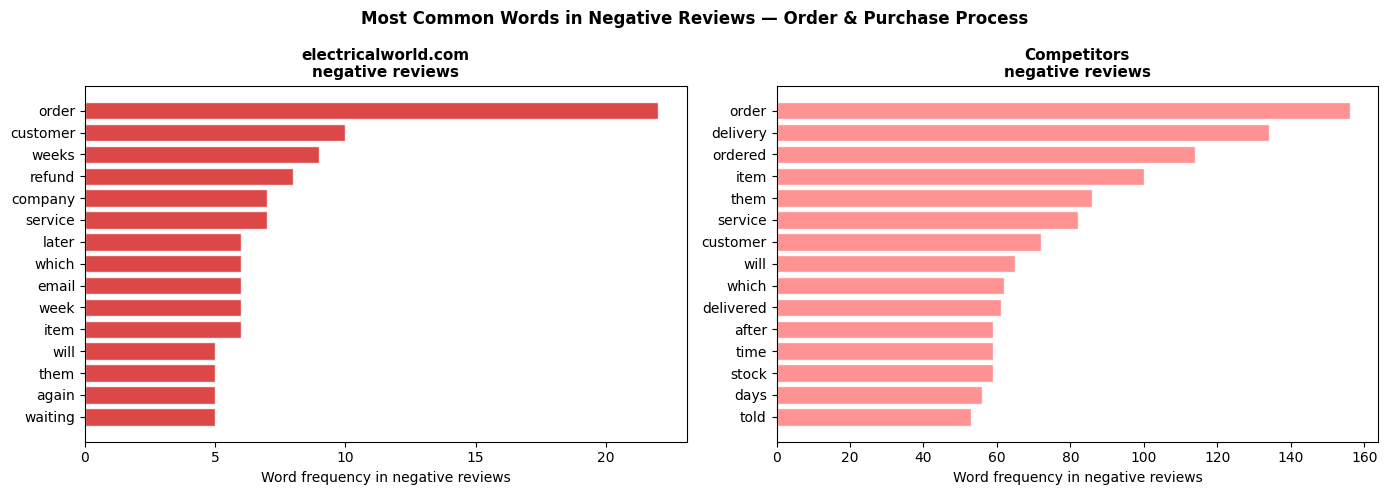

In [14]:
# ── Root cause ────────────────────────────────────────────────────
neg_reviews = nlp.root_cause_report(
    df_target=df_t, df_comp=df_c,
    merged=merged, target_name=TARGET
)

**Performance summary:**
- electricalworld.com net sentiment: **+6**
- Competitors net sentiment: **+32**
- Gap: **−27** 🔴

Despite Order & Purchase Process being our highest-volume topic
(36 reviews), we score 26 points below the sector average on net
sentiment. The gap is not caused by an isolated incident — it reflects
a **systemic pattern of operational failures** that repeats across
multiple independent customers and order IDs.

---

### What the word frequency tells us

The contrast between our negative word cloud and competitors' is
diagnostic on its own.

**Our negative reviews** are dominated by: *order, customer, weeks,
refund, company, service, later, email, week, waiting.*

This is the vocabulary of **time and abandonment** — customers waiting
for weeks, emailing repeatedly, and feeling ignored by the company.
The word "refund" appearing as the 4th most frequent term in our order
complaints confirms that failed orders frequently escalate into refund
disputes, compounding the damage.

**Competitors' negative reviews** are dominated by: *order, delivery,
ordered, item, service, customer, delivered, after, time, stock, days,
told.*

Their vocabulary is the language of **logistics and stock** — items not
delivered, stock unavailability, and being told about delays. These are
supply chain problems, not service culture problems. Critically, words
like *weeks* and *waiting* (implying extended, unresolved situations)
are absent from competitors' most frequent terms. Their customers are
frustrated by delays measured in **days**; ours are frustrated by
waits measured in **weeks**.

This single distinction defines the strategic difference: competitors
have delivery problems that are communicated and resolved relatively
quickly. We have delivery problems that are left unresolved and
unanswered for extended periods, turning an operational issue into a
trust and reputation crisis.

---

### **Review-by-review breakdown**


**[1] ★☆☆☆☆ — "Purchased tulip spinners" (sim=0.20)**

> *"web page shows multiple colours... items turned up and they were
> all red... they said that they only have the red ones. If I had known
> this I would not have purchased them, as they were specifically for
> my autistic granddaughter."*

**What went wrong:** The product listing displayed colour options that
did not correspond to actual stock availability. The customer
specifically selected based on the displayed variety and only
discovered the inaccuracy after receiving the goods and contacting
support.

**Why it matters beyond this review:** This is a **catalogue integrity
failure**. Every product listing that shows options not in stock is an
active trap for future customers. The emotional weight of this review
— a purchase made for a vulnerable child — is exactly the type of
story that gets shared and amplifies reputational damage far beyond
the single review.

**Actions:**
- Audit all product listings with variant options (colour, size,
  specification). Flag any where the displayed variants don't match
  current warehouse stock.
- Implement a real-time stock-to-listing sync so out-of-stock variants
  are either removed or marked unavailable before purchase.
- Add a "contact us before ordering" prompt on any product with
  limited variant availability as a short-term fix while the catalogue
  is audited.

---

**[2] ★☆☆☆☆ — "Terrible customer service" (sim=0.40) — Order 441459**

> *"product is faulty, I've been trying to get in touch through
> website can't get anyone, very poor customer service. Still no reply
> 2 weeks later."*

**What went wrong:** A faulty product was delivered. The customer
attempted to initiate a return or complaint through the website contact
channel and received no response for at least two weeks.

**Why it matters beyond this review:** This is **the same order
number (441459) referenced in Review 5** — meaning at least two
separate customers received faulty goods from the same order and
independently reported being unable to reach anyone. This is not a
customer service miss; it is a **batch quality failure** combined with
a **contact channel breakdown**. The website contact form either did
not deliver the message or the team did not action it.

**Actions:**
- Immediately investigate Order 441459. Identify how many units were
  dispatched, how many were faulty, and whether any customers remain
  uncontacted.
- Test every customer contact channel right now — website form,
  email, phone — and confirm messages are being received and routed
  to the correct team.
- Implement an automated acknowledgement email for every contact form
  submission within 5 minutes of receipt. A customer who receives an
  immediate reference number knows their message landed.

---

**[3] ★☆☆☆☆ — "Disgusting customer care" (sim=0.41)**

> *"Order delayed. Impossible to speak to company representatives.
> Conflicting information given in emails firstly saying item has been
> despatched and later email confirming item will be delayed. Tracking
> link in emails not working."*

**What went wrong:** Three simultaneous failures — a delayed order,
automated emails that contradicted each other (dispatch confirmed then
delay confirmed), and a broken tracking link. None of these require
the customer to experience all three; each alone would generate a
complaint. Experiencing all three simultaneously produces a 1-star
review with the word "disgusting".

**Why it matters beyond this review:** The conflicting email sequence
— *"dispatched" followed by "actually delayed"* — is almost certainly
an automated trigger logic problem in the order management system. If
it happened to this customer it is happening to others. The broken
tracking link is also a system-level fault, not a one-off.

**Actions:**
- Map the automated email trigger sequence in the order management
  system. Identify the condition that fires a dispatch confirmation
  before the order has physically left the warehouse and fix it.
- Test every tracking link template in every outbound email. If
  the tracking integration is broken, disable the tracking link
  entirely until fixed — a missing link is less damaging than a
  broken one.
- Add a manual review step before any order status changes from
  "dispatched" back to "delayed" — this state transition should
  trigger a human call or personal email, not an automated message.

---

**[4] ★☆☆☆☆ — "Waiting for my order!!" (sim=0.42) — Order 434464**

> *"Order placed 17th Sept. Chasing since 8th Oct... Customer Service
> team have replied... but they just repeat that team is working to
> expedite shipping or shipment will be in 10-14 days but still
> waiting. Have asked how quickly I can get a refund if I cancel order
> but they never seem to address that question."*

**What went wrong:** An order placed in September was still undelivered
in October. Customer service agents responded to emails but provided
only scripted, non-committal responses. When the customer directly
asked about their cancellation and refund rights, the question was
ignored across multiple interactions.

**Why it matters beyond this review:** This review exposes a critical
**agent empowerment failure**. The customer service team is clearly
operating from a script that does not include resolution authority.
Agents cannot — or are not permitted to — answer the single most
important question an affected customer can ask: *"Can I cancel and
get my money back?"* The inability to answer this question does not
just frustrate the customer; it constitutes a potential breach of
consumer rights obligations under UK consumer law, which requires
clear information about cancellation rights.

**Actions:**
- Rewrite the customer service escalation script to include a
  mandatory response path for cancellation and refund requests.
  Agents must be able to give a definitive answer, not a deferral.
- Grant front-line agents authority to initiate cancellations and
  refunds for orders delayed beyond a defined threshold (e.g. 14
  days beyond the estimated delivery date) without supervisor
  approval.
- Review compliance with UK Consumer Rights Act 2015 obligations
  regarding cancellation rights communication. Legal review
  recommended.
- Set an internal SLA: any customer who asks about cancellation must
  receive a direct, specific answer within 24 hours.

---

**[5] ★☆☆☆☆ — "Avoid dealing with this company" (sim=0.48) — Order 441459**

> *"Avoid dealing with this company, I received faulty goods tried
> reaching out can't get anyone, terrible customer service, waste of
> money, better companies out there to deal with."*

**What went wrong:** The same Order 441459 from Review 2. A second
affected customer, independently writing a review, describing the same
experience: faulty goods received, unable to reach the company.

**Why it matters beyond this review:** Two independent customers,
same order number, same complaints, same outcome. This is the
definition of a systemic failure. The phrase *"better companies out
there to deal with"* is the most commercially damaging type of review
language — it is a direct recommendation to prospective customers to
shop elsewhere. On Trustpilot, where purchasing decisions are directly
influenced by recent reviews, this language actively reduces
conversion.

---
## **6. Project Summary & Conclusions**

### What we set out to do
This project applied an end-to-end NLP pipeline to 5,729 Trustpilot
reviews across the Electronics & Technology sector to answer four
business questions: the overall sentiment balance, the topics customers
discuss, the sentiment per topic, and where electricalworld.com
outperforms or underperforms its competitors.

### What the data shows

**Overall position:**
electricalworld.com sits at the **4th percentile** of its sector
with an average of 3.00 stars and a 40% positive / 40% negative
split — matching the sector's worst performers. 96% of competitors
have a higher average rating.

**Topic landscape:**
The company's review volume concentrates almost entirely on two topics
— order and delivery — which together account for 71 of 100 reviews.
Competitors generate meaningful review volume across all 8 macro topics,
building a more complete and resilient reputation profile.

**Where we genuinely outperform:**
- **Price & Value** (net +86, gap +50 vs competitors) — customers who
  comment on pricing are overwhelmingly satisfied. This is a real
  competitive advantage that is currently invisible in the overall
  rating because it is drowned out by operational failures.
- **Product Quality & Condition** (net +100, gap +81) — when the
  product arrives correctly, customers are delighted with it.

**Where we structurally underperform:**
- **Repair & Technical Service** (gap −38) — the sector turns repair
  into a positive experience; we do not.
- **Order & Purchase Process** (gap −27) — our highest-volume topic is
  also our most damaging gap. Delay, miscommunication, and
  unreachability are the three recurring failure modes in the raw
  reviews.
- **Returns, Refunds & Cancellations** (net −53, gap −4) — equally
  bad as the sector, which sets a low bar we should still aim to
  clear.

### The central insight
electricalworld.com has a **good product at a good price delivered
badly**. The product quality and pricing signals are genuinely
positive. The operational execution — fulfilment timing, order
communication, customer service responsiveness, and returns handling —
is what is destroying the rating. This is strategically important
because operational problems are fixable. A company with a bad product
has a much harder path to improvement than a company with good products
and broken processes.

### Priority action roadmap

| Priority | Area | Expected impact |
|----------|------|----------------|
| 🔴 1 | Fix order communication — tracking links, accurate status emails | Reduces inbound contacts, improves delivery sentiment |
| 🔴 2 | Empower CS agents to resolve cancellations and refunds autonomously | Reduces escalation, improves order and refund sentiment |
| 🔴 3 | Establish 24-hour first-response SLA | Directly addresses the most common complaint across all negative reviews |
| 🟡 4 | Align website product catalogue with real stock | Eliminates expectation mismatch complaints |
| 🟡 5 | Implement pre-dispatch fulfilment monitoring | Proactive outreach before the customer complains |
| 🟢 6 | Build a review generation strategy for satisfied customers | Increases positive review volume across under-represented topics |
| 🟢 7 | Market price and product quality as explicit brand strengths | Converts existing advantages into top-of-funnel differentiation |

### Final note on methodology
The combination of SBERT semantic embeddings with seed-defined macro
topics proved significantly more reliable than unsupervised BERTopic
clustering for this use case. With a target corpus of only 100 reviews,
density-based clustering produced 86% outliers. Direct cosine similarity
assignment reduced General/Other to near zero while ensuring that all
reviews contributed meaningful signal to the competitive analysis. The
use of star ratings as sentiment proxy, rather than a transformer model,
added no information loss for this dataset since ratings are a direct
and unambiguous expression of customer satisfaction. These design
decisions collectively produced results that are immediately
interpretable by a non-technical business audience — which is the
ultimate measure of success for an applied NLP project.